In [1]:
# Prof. Mina Younan
# mina.younan@mu.edu.eg

In [2]:
# ===================================================================
# 0. IMPORTS, NLTK DATA, AND RANDOM SEEDS
# ===================================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from scipy.sparse import hstack
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout,
    Concatenate, Bidirectional, GRU, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import torch
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    Trainer, TrainingArguments
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

# Download NLTK resources (run once)
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to C:\Users\Dr
[nltk_data]     Mina\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Dr
[nltk_data]     Mina\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Dr
[nltk_data]     Mina\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
# ===================================================================
# 1. CONTRACTION MAPPING (used by both DS1 and DS2 cleaning)
# ===================================================================

CONTRACTION_MAP = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "'cause": "because", "could've": "could have", "couldn't": "could not", "couldn't've": "could not have",
    "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hadn't've": "had not have", "hasn't": "has not", "haven't": "have not", "he'd": "he would",
    "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have", "he's": "he is",
    "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
    "i'd": "i would", "i'd've": "i would have", "i'll": "i will", "i'll've": "i will have",
    "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have",
    "it'll": "it will", "it'll've": "it will have", "it's": "it is", "let's": "let us",
    "ma'am": "madam", "mayn't": "may not", "might've": "might have", "mightn't": "might not",
    "mightn't've": "might not have", "must've": "must have", "mustn't": "must not",
    "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have",
    "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have",
    "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
    "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have",
    "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have",
    "so've": "so have", "so's": "so is", "that'd": "that would", "that'd've": "that would have",
    "that's": "that is", "there'd": "there would", "there'd've": "there would have",
    "there's": "there is", "they'd": "they would", "they'd've": "they would have",
    "they'll": "they will", "they'll've": "they will have", "they're": "they are",
    "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would",
    "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have",
    "what're": "what are", "what's": "what is", "what've": "what have", "when's": "when is",
    "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have",
    "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
    "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not",
    "won't've": "will not have", "would've": "would have", "wouldn't": "would not",
    "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would",
    "y'all'd've": "you all would have", "y'all're": "you all are", "y'all've": "you all have",
    "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
    "you're": "you are", "you've": "you have"
}

def expand_contractions(text):
    if not isinstance(text, str):
        return text
    for contraction, expansion in sorted(CONTRACTION_MAP.items(), key=lambda x: len(x[0]), reverse=True):
        pattern = r'\b' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text, flags=re.IGNORECASE)
    return text

In [4]:
# ===================================================================
# 2. CLEANING FUNCTION (shared by DS1 and DS2)
# ===================================================================

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Remove Skytrax boilerplate
    text = re.sub(r'✅\s*Trip\s*Verified\s*\|\s*', '', text)
    text = re.sub(r'Trip\s*Verified\s*\|\s*', '', text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-zA-Z\s\']', ' ', text)
    text = expand_contractions(text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize and lemmatize
    words = re.findall(r"[a-zA-Z]+(?:'[a-zA-Z]+)?", text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

In [5]:
# ===================================================================
# 3. LOAD, CLEAN, AND REMOVE OUTLIERS FROM DS1
# ===================================================================

# Load DS1
file_path_ds1 = "DS1.csv"  # change to your path
df1 = pd.read_csv(file_path_ds1)

# Drop missing and duplicates
df1 = df1.dropna(subset=['customer_review', 'recommended'])
df1 = df1.drop_duplicates(subset=['customer_review'])

# Clean reviews
df1['cleaned_review'] = df1['customer_review'].apply(clean_text)
df1 = df1[df1['cleaned_review'].str.len() > 0]
df1['class_label'] = df1['recommended'].astype(int)

# Outlier removal (IQR on text length)
df1['text_length'] = df1['cleaned_review'].apply(len)
Q1, Q3 = df1['text_length'].quantile(0.25), df1['text_length'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df1_clean = df1[(df1['text_length'] >= lower) & (df1['text_length'] <= upper)]

df1_clean.to_csv("DS1_cleaned_no_outliers.csv", index=False)
print(f"DS1 cleaned shape: {df1_clean.shape}")

DS1 cleaned shape: (5175, 13)


In [6]:
# ===================================================================
# 4. LOAD, CLEAN, AND REMOVE OUTLIERS FROM DS2
# ===================================================================

file_path_ds2 = "DS2.csv"
df2 = pd.read_csv(file_path_ds2)

# Identify text column
text_col = 'review_text' if 'review_text' in df2.columns else None
if text_col is None:
    for col in df2.columns:
        if 'review' in col.lower() or 'comment' in col.lower():
            text_col = col
            break
    if text_col is None:
        raise KeyError("No review text column found in DS2")

# Assign class labels: violent_aggressive → 2, else use recommended (no=0, yes=1)
def assign_class(row):
    if pd.notna(row.get('manual_label')) and str(row['manual_label']).lower() == 'violent_aggressive':
        return 2
    if pd.notna(row.get('recommended')):
        rec = str(row['recommended']).lower()
        if rec == 'no': return 0
        if rec == 'yes': return 1
    return np.nan

df2['class_label'] = df2.apply(assign_class, axis=1)
df2 = df2.dropna(subset=['class_label'])
df2['class_label'] = df2['class_label'].astype(int)


# Clean text
df2['cleaned_review'] = df2[text_col].apply(clean_text)
df2 = df2[df2['cleaned_review'].str.len() > 0]

# Outlier removal
df2['text_length'] = df2['cleaned_review'].apply(len)
Q1, Q3 = df2['text_length'].quantile(0.25), df2['text_length'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df2_clean = df2[(df2['text_length'] >= lower) & (df2['text_length'] <= upper)]

df2_clean.to_csv("DS2_cleaned.csv", index=False)
print(f"DS2 cleaned shape: {df2_clean.shape}")

DS2 cleaned shape: (300, 29)


In [7]:
# ===================================================================
# 5. MERGE CLEANED DATASETS
# ===================================================================

df1 = pd.read_csv("DS1_cleaned_no_outliers.csv")
df2 = pd.read_csv("DS2_cleaned.csv")

df1_merge = df1[['cleaned_review', 'class_label']].copy()
df2_merge = df2[['cleaned_review', 'class_label']].copy()

df1_merge['source'] = 'DS1'
df2_merge['source'] = 'DS2'

mrgds = pd.concat([df1_merge, df2_merge], axis=0, ignore_index=True)
mrgds = mrgds.drop_duplicates(subset=['cleaned_review'])

mrgds.to_csv("MrgDS.csv", index=False)
print(f"Merged dataset shape: {mrgds.shape}")

Merged dataset shape: (5475, 3)


In [8]:
import transformers
import tensorflow as tf
print("Transformers version:", transformers.__version__)
print("TensorFlow version:", tf.__version__)

Transformers version: 5.9.0
TensorFlow version: 2.21.0


In [9]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             auc, f1_score, precision_score, recall_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Embedding, Conv1D, GlobalMaxPooling1D,
                                     Dense, Dropout, Input, Concatenate,
                                     BatchNormalization, Bidirectional, GRU,
                                     GlobalAveragePooling1D, Attention, LSTM)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Transformers
#from transformers import DistilBertTokenizer, TFAutoModelForSequenceClassification
from transformers import DistilBertTokenizer, AutoModelForSequenceClassification

from imblearn.over_sampling import RandomOverSampler

# Set seeds
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Output directories
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

Dataset shape: (5475, 3)
                                      cleaned_review  class_label source
0  london to izmir via istanbul first time id flo...            0    DS1
1  istanbul to bucharest we make our check in in ...            1    DS1

Class distribution:
class_label
0    2991
1    2184
2     300
Name: count, dtype: int64


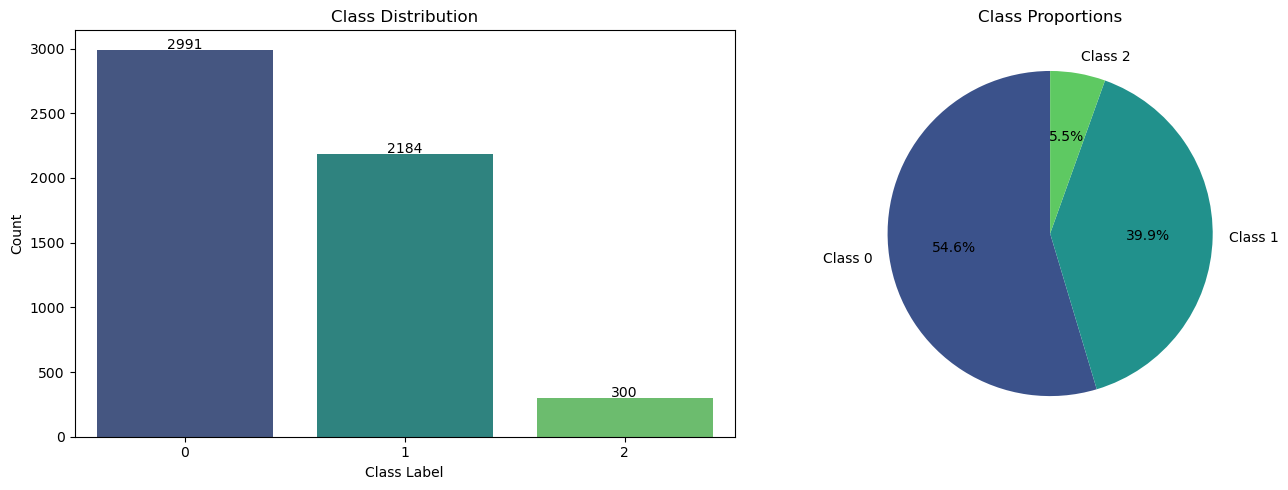

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('MrgDS.csv')
print(f"Dataset shape: {df.shape}")
print(df.head(2))

# Get class distribution
class_counts = df['class_label'].value_counts().sort_index()

print("\nClass distribution:")
print(class_counts)

# === FIXED VISUALIZATION ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.barplot(x=class_counts.index.astype(str), 
            y=class_counts.values, 
            ax=axes[0], 
            palette='viridis')  # better for multiple classes

axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Count')

# Add count labels on bars
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Pie chart - FIXED
labels = [f'Class {idx}' for idx in class_counts.index]

axes[1].pie(class_counts.values, 
            labels=labels, 
            autopct='%1.1f%%',
            colors=sns.color_palette('viridis', len(class_counts)),
            startangle=90)

axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()


Class distribution by source:
class_label     0     1    2
source                      
DS1          2991  2184    0
DS2             0     0  300


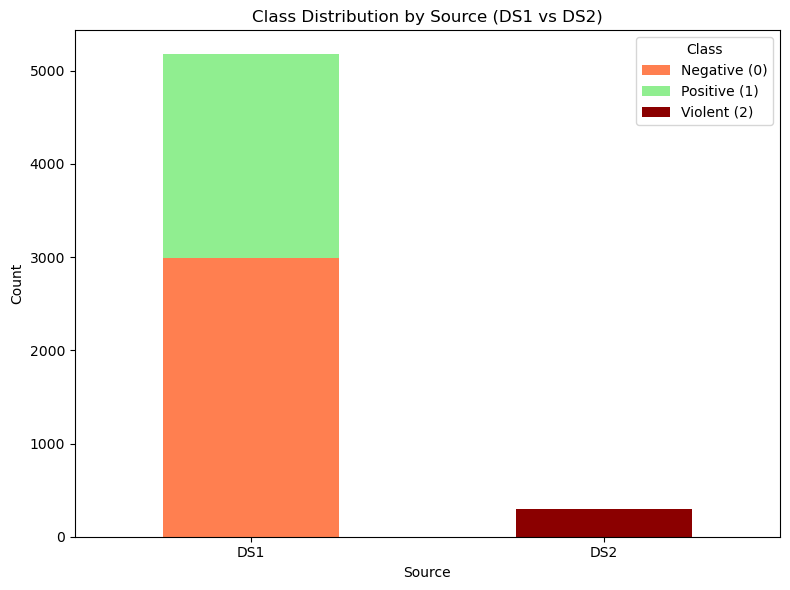

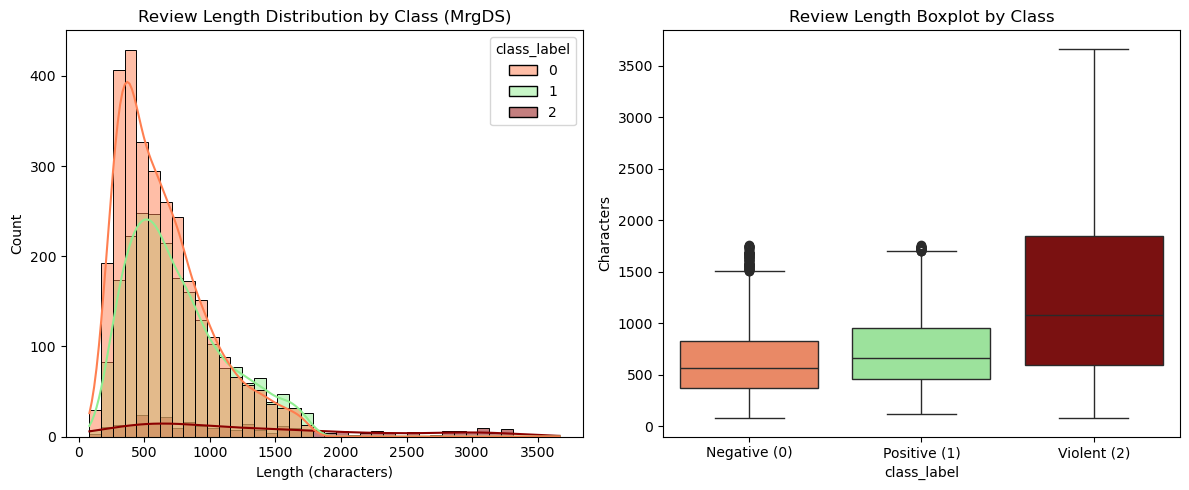


=== MRGDS MERGING REPORT ===
Total samples in MrgDS: 5475
Class distribution:
class_label
0    2991
1    2184
2     300
Name: count, dtype: int64
Average text length: 720.8 chars
Min length: 81, Max length: 3667

Samples per source:
source
DS1    5175
DS2     300
Name: count, dtype: int64
STEP 3 COMPLETED. MRGDS.CSV SAVED.


In [12]:
# -------------------------------------------------------------------
# 7. Class distribution by source (DS1 vs DS2)
# -------------------------------------------------------------------
source_counts = pd.crosstab(mrgds['source'], mrgds['class_label'])
print("\nClass distribution by source:")
print(source_counts)

source_counts.plot(kind='bar', stacked=True, figsize=(8, 6), color=['coral', 'lightgreen', 'darkred'])
plt.title('Class Distribution by Source (DS1 vs DS2)')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Class', labels=['Negative (0)', 'Positive (1)', 'Violent (2)'])
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 8. Text length statistics in merged dataset
# -------------------------------------------------------------------
mrgds['text_length'] = mrgds['cleaned_review'].apply(len)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=mrgds, x='text_length', hue='class_label', bins=40, kde=True, palette=['coral', 'lightgreen', 'darkred'])
plt.title('Review Length Distribution by Class (MrgDS)')
plt.xlabel('Length (characters)')

plt.subplot(1, 2, 2)
sns.boxplot(x='class_label', y='text_length', data=mrgds, palette=['coral', 'lightgreen', 'darkred'])
plt.xticks([0,1,2], ['Negative (0)', 'Positive (1)', 'Violent (2)'])
plt.title('Review Length Boxplot by Class')
plt.ylabel('Characters')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 9. Summary report
# -------------------------------------------------------------------
print("\n=== MRGDS MERGING REPORT ===")
print(f"Total samples in MrgDS: {len(mrgds)}")
print(f"Class distribution:\n{class_counts}")
print(f"Average text length: {mrgds['text_length'].mean():.1f} chars")
print(f"Min length: {mrgds['text_length'].min()}, Max length: {mrgds['text_length'].max()}")
print(f"\nSamples per source:\n{mrgds['source'].value_counts()}")
print("="*60)
print("STEP 3 COMPLETED. MRGDS.CSV SAVED.")
print("="*60)

In [13]:
X = df['cleaned_review'].values
y = df['class_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Balance only training set
ros = RandomOverSampler(random_state=SEED)
X_train_res, y_train_res = ros.fit_resample(X_train.reshape(-1,1), y_train)
X_train_res = X_train_res.ravel()

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("Train class distribution (before balancing):")
print(pd.Series(y_train).value_counts().sort_index())
print("\nAfter oversampling (balanced):")
print(pd.Series(y_train_res).value_counts().sort_index())
print("\nTest set (imbalanced):")
print(pd.Series(y_test).value_counts().sort_index())

Train size: 4380, Test size: 1095
Train class distribution (before balancing):
0    2393
1    1747
2     240
Name: count, dtype: int64

After oversampling (balanced):
0    2393
1    2393
2    2393
Name: count, dtype: int64

Test set (imbalanced):
0    598
1    437
2     60
Name: count, dtype: int64



MODEL 1: TF-IDF (word+char) + Linear SVM
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       598
           1       0.84      0.83      0.83       437
           2       0.85      0.73      0.79        60

    accuracy                           0.86      1095
   macro avg       0.86      0.82      0.84      1095
weighted avg       0.86      0.86      0.86      1095



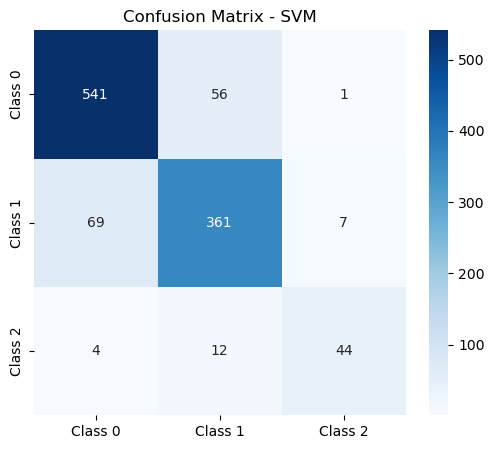

Macro ROC-AUC (SVM): 0.9544
Class 2 ROC-AUC (SVM): 0.9939


In [14]:
print("\n" + "="*60)
print("MODEL 1: TF-IDF (word+char) + Linear SVM")
print("="*60)

word_tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=10000,
                             sublinear_tf=True, stop_words='english')
char_tfidf = TfidfVectorizer(analyzer='char', ngram_range=(3,6),
                             max_features=10000, sublinear_tf=True)

X_train_word = word_tfidf.fit_transform(X_train_res)
X_train_char = char_tfidf.fit_transform(X_train_res)
X_train_tfidf = np.hstack((X_train_word.toarray(), X_train_char.toarray()))

X_test_word = word_tfidf.transform(X_test)
X_test_char = char_tfidf.transform(X_test)
X_test_tfidf = np.hstack((X_test_word.toarray(), X_test_char.toarray()))

svm = LinearSVC(random_state=SEED, class_weight='balanced', max_iter=2000)
svm.fit(X_train_tfidf, y_train_res)
y_pred_svm = svm.predict(X_test_tfidf)

# Evaluation
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)
print(classification_report(y_test, y_pred_svm))
pd.DataFrame(report_svm).transpose().to_csv('results/svm_report.csv')

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0','Class 1','Class 2'],
            yticklabels=['Class 0','Class 1','Class 2'])
plt.title('Confusion Matrix - SVM')
plt.savefig('figures/cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score_svm = svm.decision_function(X_test_tfidf)
roc_auc_svm = roc_auc_score(y_test_bin, y_score_svm, average='macro')
print(f"Macro ROC-AUC (SVM): {roc_auc_svm:.4f}")

# Per-class AUC for class 2
svm_auc_c2 = roc_auc_score((y_test == 2).astype(int), y_score_svm[:, 2])
print(f"Class 2 ROC-AUC (SVM): {svm_auc_c2:.4f}")

In [15]:
import os
if os.path.exists("glove/glove.6B.100d.txt"):
    print("✅ GloVe ready!")
else:
    print("❌ File not found. Check extraction path.")

✅ GloVe ready!


In [16]:
MAX_SEQ_LEN = 200
VOCAB_SIZE = 20000
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_res)

X_train_seq = tokenizer.texts_to_sequences(X_train_res)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train_res, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# Load GloVe embeddings
embeddings_index = {}
with open('glove/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        emb_vec = embeddings_index.get(word)
        if emb_vec is not None:
            embedding_matrix[i] = emb_vec


MODEL 2: Improved TextCNN (GloVe)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 200)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 200, 100)          │       2,000,000 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 198, 128)          │          38,528 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 197, 128)          │          51,328 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 196, 128)          │          64,128 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 128)               │               0 │ conv1d[0][0]               │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_1        │ (None, 128)               │               0 │ conv1d_1[0][0]             │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_2        │ (None, 128)               │               0 │ conv1d_2[0][0]             │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 384)               │               0 │ global_max_pooling1d[0][0… │
│                               │                           │                 │ global_max_pooling1d_1[0]… │
│                               │                           │                 │ global_max_pooling1d_2[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 384)               │           1,536 │ concatenate[0][0]          │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          49,280 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 3)                 │             387 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,205,187 (8.41 MB)

 Trainable params: 2,204,419 (8.41 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 73s 337ms/step - accuracy: 0.7607 - loss: 0.6024 - val_accuracy: 0.9903 - val_loss: 0.1475
Epoch 2/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 121s 531ms/step - accuracy: 0.9415 - loss: 0.1602 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 3/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 93s 282ms/step - accuracy: 0.9799 - loss: 0.0640 - val_accuracy: 1.0000 - val_loss: 8.9483e-04
Epoch 4/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 53s 261ms/step - accuracy: 0.9927 - loss: 0.0265 - val_accuracy: 1.0000 - val_loss: 9.8569e-04
Epoch 5/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 82s 260ms/step - accuracy: 0.9958 - loss: 0.0167 - val_accuracy: 1.0000 - val_loss: 8.9561e-05
Epoch 6/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 96s 330ms/step - accuracy: 0.9966 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 3.2322e-05
Epoch 7/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 104s 438ms/step - accuracy: 0.9964 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 9.4962e-04
Epoch 8/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 120s 327ms/step - acc

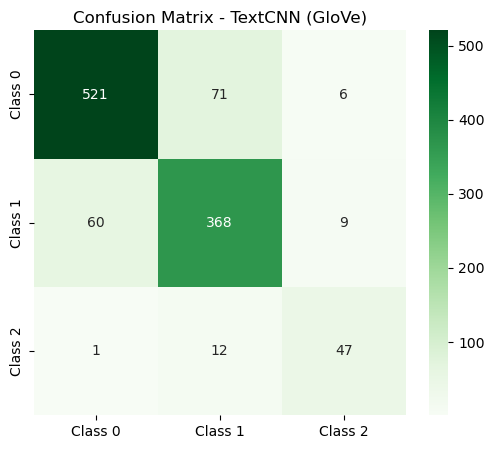

Macro ROC-AUC (TextCNN): 0.9512
Class 2 ROC-AUC (TextCNN): 0.9798


In [17]:
print("\n" + "="*60)
print("MODEL 2: Improved TextCNN (GloVe)")
print("="*60)

def build_textcnn(embedding_matrix):
    inputs = Input(shape=(MAX_SEQ_LEN,))
    emb = Embedding(VOCAB_SIZE, EMBED_DIM, weights=[embedding_matrix],
                    trainable=True)(inputs)
    conv3 = Conv1D(128, 3, activation='relu')(emb)
    conv3 = GlobalMaxPooling1D()(conv3)
    conv4 = Conv1D(128, 4, activation='relu')(emb)
    conv4 = GlobalMaxPooling1D()(conv4)
    conv5 = Conv1D(128, 5, activation='relu')(emb)
    conv5 = GlobalMaxPooling1D()(conv5)
    concat = Concatenate()([conv3, conv4, conv5])
    bn = BatchNormalization()(concat)
    dense = Dense(128, activation='relu')(bn)
    drop = Dropout(0.5)(dense)
    outputs = Dense(3, activation='softmax')(drop)
    return Model(inputs, outputs)

textcnn = build_textcnn(embedding_matrix)
textcnn.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
textcnn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_cnn = textcnn.fit(X_train_pad, y_train_cat,
                          validation_split=0.1,
                          epochs=20, batch_size=32,
                          callbacks=[early_stop], verbose=1)

y_pred_cnn = textcnn.predict(X_test_pad)
y_pred_cnn_class = np.argmax(y_pred_cnn, axis=1)

report_cnn = classification_report(y_test, y_pred_cnn_class, output_dict=True)
print(classification_report(y_test, y_pred_cnn_class))
pd.DataFrame(report_cnn).transpose().to_csv('results/textcnn_report.csv')

cm_cnn = confusion_matrix(y_test, y_pred_cnn_class)
plt.figure(figsize=(6,5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Class 0','Class 1','Class 2'],
            yticklabels=['Class 0','Class 1','Class 2'])
plt.title('Confusion Matrix - TextCNN (GloVe)')
plt.savefig('figures/cm_textcnn.png', dpi=150, bbox_inches='tight')
plt.show()

roc_auc_cnn = roc_auc_score(y_test_bin, y_pred_cnn, average='macro')
print(f"Macro ROC-AUC (TextCNN): {roc_auc_cnn:.4f}")
cnn_auc_c2 = roc_auc_score((y_test == 2).astype(int), y_pred_cnn[:, 2])
print(f"Class 2 ROC-AUC (TextCNN): {cnn_auc_c2:.4f}")

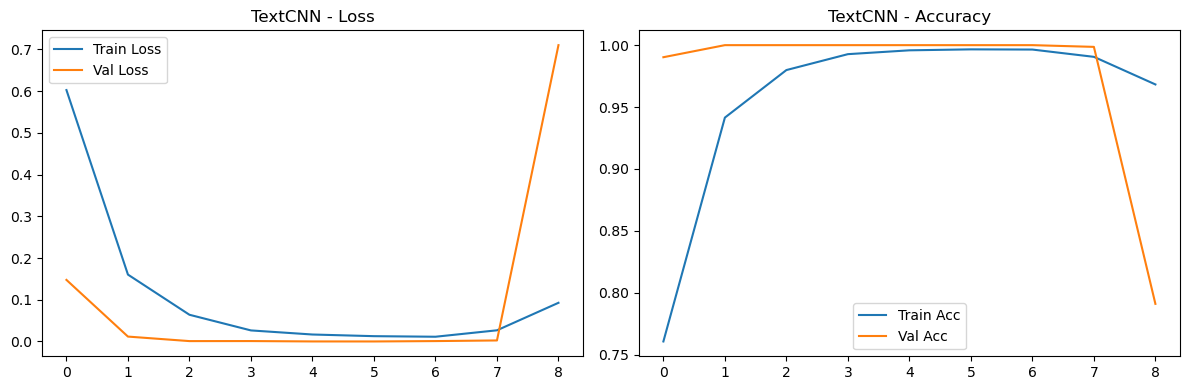

In [30]:
# Plot training curves
def plot_history(hist, title, fname):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_cnn, 'TextCNN', 'textCNN_history.png')


MODEL 3: Parallel CNN-BiGRU + Attention (GloVe)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 200)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 200, 100)          │       2,000,000 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 200, 128)          │          63,744 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_3 (Conv1D)             │ (None, 198, 128)          │          38,528 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention (Attention)         │ (None, 200, 128)          │               0 │ bidirectional[0][0],       │
│                               │                           │                 │ bidirectional[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_3        │ (None, 128)               │               0 │ conv1d_3[0][0]             │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 128)               │               0 │ attention[0][0]            │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 256)               │               0 │ global_max_pooling1d_3[0]… │
│                               │                           │                 │ global_average_pooling1d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 128)               │          32,896 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 128)               │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 3)                 │             387 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,135,555 (8.15 MB)

 Trainable params: 2,135,555 (8.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 151s 672ms/step - accuracy: 0.6802 - loss: 0.7027 - val_accuracy: 0.9331 - val_loss: 0.1921
Epoch 2/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 118s 551ms/step - accuracy: 0.8886 - loss: 0.2803 - val_accuracy: 0.9972 - val_loss: 0.0226
Epoch 3/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 112s 556ms/step - accuracy: 0.9325 - loss: 0.1806 - val_accuracy: 1.0000 - val_loss: 0.0031
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       598
           1       0.76      0.87      0.81       437
           2       0.80      0.78      0.79        60

    accuracy                           0.84      1095
   macro avg       0.82      0.82      0.82      1095
weighted avg       0.84      0.84      0.84      1095



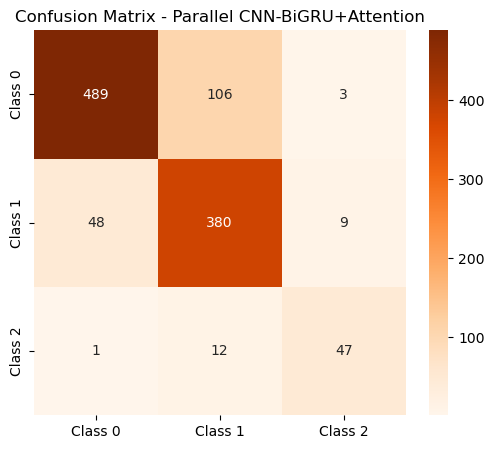

Macro ROC-AUC (Parallel): 0.9454
Class 2 ROC-AUC (Parallel): 0.9876


In [18]:
print("\n" + "="*60)
print("MODEL 3: Parallel CNN-BiGRU + Attention (GloVe)")
print("="*60)

def build_parallel(embedding_matrix):
    inputs = Input(shape=(MAX_SEQ_LEN,))
    emb = Embedding(VOCAB_SIZE, EMBED_DIM, weights=[embedding_matrix],
                    trainable=True)(inputs)
    # CNN branch
    cnn = Conv1D(128, 3, activation='relu')(emb)
    cnn = GlobalMaxPooling1D()(cnn)
    # BiGRU with self-attention
    bigru = Bidirectional(GRU(64, return_sequences=True))(emb)
    attn = Attention()([bigru, bigru])
    bigru_pool = GlobalAveragePooling1D()(attn)
    concat = Concatenate()([cnn, bigru_pool])
    dense = Dense(128, activation='relu')(concat)
    drop = Dropout(0.5)(dense)
    outputs = Dense(3, activation='softmax')(drop)
    return Model(inputs, outputs)

parallel = build_parallel(embedding_matrix)
parallel.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
parallel.summary()

history_par = parallel.fit(X_train_pad, y_train_cat,
                           validation_split=0.1,
                           epochs=20, batch_size=32,
                           callbacks=[early_stop], verbose=1)

y_pred_par = parallel.predict(X_test_pad)
y_pred_par_class = np.argmax(y_pred_par, axis=1)

report_par = classification_report(y_test, y_pred_par_class, output_dict=True)
print(classification_report(y_test, y_pred_par_class))
pd.DataFrame(report_par).transpose().to_csv('results/parallel_report.csv')

cm_par = confusion_matrix(y_test, y_pred_par_class)
plt.figure(figsize=(6,5))
sns.heatmap(cm_par, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Class 0','Class 1','Class 2'],
            yticklabels=['Class 0','Class 1','Class 2'])
plt.title('Confusion Matrix - Parallel CNN-BiGRU+Attention')
plt.savefig('figures/cm_parallel.png', dpi=150, bbox_inches='tight')
plt.show()

roc_auc_par = roc_auc_score(y_test_bin, y_pred_par, average='macro')
print(f"Macro ROC-AUC (Parallel): {roc_auc_par:.4f}")
par_auc_c2 = roc_auc_score((y_test == 2).astype(int), y_pred_par[:, 2])
print(f"Class 2 ROC-AUC (Parallel): {par_auc_c2:.4f}")

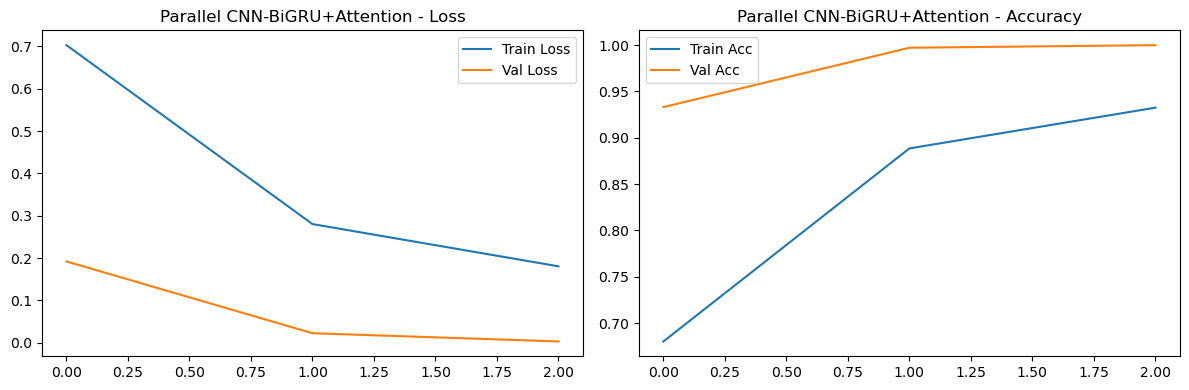

In [31]:
plot_history(history_par, 'Parallel CNN-BiGRU+Attention', 'Parallel CNN-BiGRU+Attention_history.png')


MODEL 4: BiLSTM (GloVe)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_2 (Embedding)              │ (None, 200, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 200, 128)            │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,125,891 (8.11 MB)

 Trainable params: 2,125,891 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 158s 662ms/step - accuracy: 0.7052 - loss: 0.6493 - val_accuracy: 0.9513 - val_loss: 0.1963
Epoch 2/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 133s 660ms/step - accuracy: 0.8534 - loss: 0.3851 - val_accuracy: 0.9833 - val_loss: 0.0702
Epoch 3/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 131s 648ms/step - accuracy: 0.8937 - loss: 0.3055 - val_accuracy: 1.0000 - val_loss: 0.0169
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 218ms/step
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       598
           1       0.73      0.64      0.68       437
           2       0.70      0.85      0.77        60

    accuracy                           0.75      1095
   macro avg       0.73      0.77      0.75      1095
weighted avg       0.75      0.75      0.75      1095



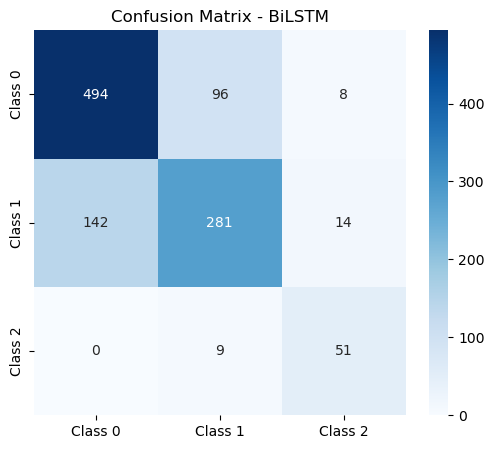

Macro ROC-AUC (BiLSTM): 0.8838
Class 2 ROC-AUC (BiLSTM): 0.9751


In [19]:
print("\n" + "="*60)
print("MODEL 4: BiLSTM (GloVe)")
print("="*60)

def build_bilstm(embedding_matrix):
    inputs = Input(shape=(MAX_SEQ_LEN,))
    emb = Embedding(VOCAB_SIZE, EMBED_DIM, weights=[embedding_matrix],
                    trainable=True)(inputs)
    bilstm = Bidirectional(LSTM(64, return_sequences=True))(emb)
    bilstm = Bidirectional(LSTM(32))(bilstm)
    drop = Dropout(0.5)(bilstm)
    outputs = Dense(3, activation='softmax')(drop)
    return Model(inputs, outputs)

bilstm = build_bilstm(embedding_matrix)
bilstm.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
bilstm.summary()

history_bilstm = bilstm.fit(X_train_pad, y_train_cat,
                            validation_split=0.1,
                            epochs=20, batch_size=32,
                            callbacks=[early_stop], verbose=1)

y_pred_bilstm = bilstm.predict(X_test_pad)
y_pred_bilstm_class = np.argmax(y_pred_bilstm, axis=1)

report_bilstm = classification_report(y_test, y_pred_bilstm_class, output_dict=True)
print(classification_report(y_test, y_pred_bilstm_class))
pd.DataFrame(report_bilstm).transpose().to_csv('results/bilstm_report.csv')

cm_bilstm = confusion_matrix(y_test, y_pred_bilstm_class)
plt.figure(figsize=(6,5))
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0','Class 1','Class 2'],
            yticklabels=['Class 0','Class 1','Class 2'])
plt.title('Confusion Matrix - BiLSTM')
plt.savefig('figures/cm_bilstm.png', dpi=150, bbox_inches='tight')
plt.show()

roc_auc_bilstm = roc_auc_score(y_test_bin, y_pred_bilstm, average='macro')
bilstm_auc_c2 = roc_auc_score((y_test == 2).astype(int), y_pred_bilstm[:, 2])
print(f"Macro ROC-AUC (BiLSTM): {roc_auc_bilstm:.4f}")
print(f"Class 2 ROC-AUC (BiLSTM): {bilstm_auc_c2:.4f}")

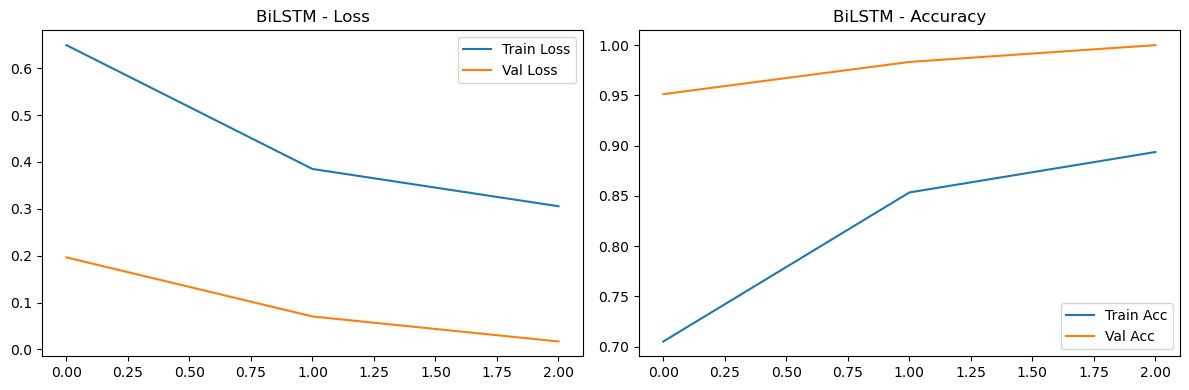

In [32]:
plot_history(history_bilstm, 'BiLSTM', 'BiLSTM_history.png')

In [20]:
# ====================================================
# DISTILBERT FINE-TUNING (PyTorch)
# ====================================================
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import DistilBertTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm

# Parameters
BERT_MAX_LEN = 128
BERT_BATCH_SIZE = 8
BERT_EPOCHS = 3

# Load tokenizer
tokenizer_bert = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def encode_texts_pytorch(texts, labels, max_len):
    """Tokenize texts and return PyTorch tensors."""
    input_ids, attention_masks = [], []
    for text in texts:
        # Direct call (no .encode_plus) – modern and recommended
        encoded = tokenizer_bert(
            text,
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'          # PyTorch tensors
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])
    return torch.stack(input_ids), torch.stack(attention_masks), torch.tensor(labels)

# Prepare data
X_train_bert, mask_train_bert, y_train_bert = encode_texts_pytorch(X_train_res, y_train_res, BERT_MAX_LEN)
X_test_bert, mask_test_bert, y_test_bert = encode_texts_pytorch(X_test, y_test, BERT_MAX_LEN)

# Split validation from training
val_size = int(0.1 * len(X_train_bert))
train_dataset = TensorDataset(X_train_bert[:-val_size], mask_train_bert[:-val_size], y_train_bert[:-val_size])
val_dataset = TensorDataset(X_train_bert[-val_size:], mask_train_bert[-val_size:], y_train_bert[-val_size:])
test_dataset = TensorDataset(X_test_bert, mask_test_bert, y_test_bert)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BERT_BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BERT_BATCH_SIZE)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model
model_bert = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)
model_bert.to(device)

# Optimizer and loss
optimizer = AdamW(model_bert.parameters(), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss()

# Training loop
best_val_loss = float('inf')
for epoch in range(BERT_EPOCHS):
    # Training
    model_bert.train()
    total_loss = 0
    for input_ids, attention_mask, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_bert(input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Train loss: {total_loss/len(train_loader):.4f}")
    
    # Validation
    model_bert.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            outputs = model_bert(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(val_loader)
    acc = correct / total
    print(f"Val loss: {val_loss:.4f}, Val acc: {acc:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_bert.state_dict(), 'best_bert_model.pt')
        print("Best model saved.")

# Load best model
model_bert.load_state_dict(torch.load('best_bert_model.pt'))

# Test evaluation
model_bert.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        outputs = model_bert(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

y_pred_bert_class = np.array(all_preds)
y_test_bert = np.array(all_labels)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report (DistilBERT):")
print(classification_report(y_test_bert, y_pred_bert_class))

Using device: cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1: 100%|█████████████████████████████████████████████████████████████████████| 808/808 [3:23:52<00:00, 15.14s/it]


Train loss: 0.3640
Val loss: 0.0644, Val acc: 0.9763
Best model saved.


Epoch 2: 100%|█████████████████████████████████████████████████████████████████████| 808/808 [2:55:17<00:00, 13.02s/it]


Train loss: 0.1595
Val loss: 0.0013, Val acc: 1.0000
Best model saved.


Epoch 3: 100%|█████████████████████████████████████████████████████████████████████| 808/808 [2:44:09<00:00, 12.19s/it]


Train loss: 0.0884
Val loss: 0.0045, Val acc: 1.0000

Classification Report (DistilBERT):
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       598
           1       0.80      0.94      0.86       437
           2       0.91      0.83      0.87        60

    accuracy                           0.88      1095
   macro avg       0.89      0.87      0.87      1095
weighted avg       0.89      0.88      0.88      1095



In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
svm_scores = {'f1_macro': [], 'auc_macro': [], 'auc_c2': []}
for train_idx, val_idx in skf.split(X_train_res, y_train_res):
    X_tr, X_val = X_train_res[train_idx], X_train_res[val_idx]
    y_tr, y_val = y_train_res[train_idx], y_train_res[val_idx]
    # Fit SVM on X_tr, y_tr (TF‑IDF inside loop)
    # Evaluate on X_val
    # Append scores
# Then report mean/std

In [25]:
# After getting predictions, add these lines:
from sklearn.metrics import classification_report, roc_auc_score

# Classification report
report_bert = classification_report(y_test_bert, y_pred_bert_class, output_dict=True)
print(classification_report(y_test_bert, y_pred_bert_class))

# ROC-AUC (macro and class 2)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
# You need probabilities, not class predictions. For ROC, we need logits or softmax.
# Re-run test with probabilities:
all_probs = []
model_bert.eval()
with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        outputs = model_bert(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
y_pred_bert_probs = np.array(all_probs)

roc_auc_bert = roc_auc_score(y_test_bin, y_pred_bert_probs, average='macro')
bert_auc_c2 = roc_auc_score((y_test == 2).astype(int), y_pred_bert_probs[:, 2])

print(f"Macro ROC-AUC (DistilBERT): {roc_auc_bert:.4f}")
print(f"Class 2 ROC-AUC (DistilBERT): {bert_auc_c2:.4f}")

              precision    recall  f1-score   support

           0       0.95      0.84      0.89       598
           1       0.80      0.94      0.86       437
           2       0.91      0.83      0.87        60

    accuracy                           0.88      1095
   macro avg       0.89      0.87      0.87      1095
weighted avg       0.89      0.88      0.88      1095

Macro ROC-AUC (DistilBERT): 0.9718
Class 2 ROC-AUC (DistilBERT): 0.9927



=== FINAL COMPARISON TABLE ===
        Model  Macro F1  Macro ROC-AUC  Class 2 ROC-AUC
0         SVM  0.837391       0.954391         0.993897
1     TextCNN  0.827457       0.951224         0.979807
2    Parallel  0.821222       0.945418         0.987617
3      BiLSTM  0.750144       0.883817         0.975056
4  DistilBERT  0.874354       0.971762         0.992673


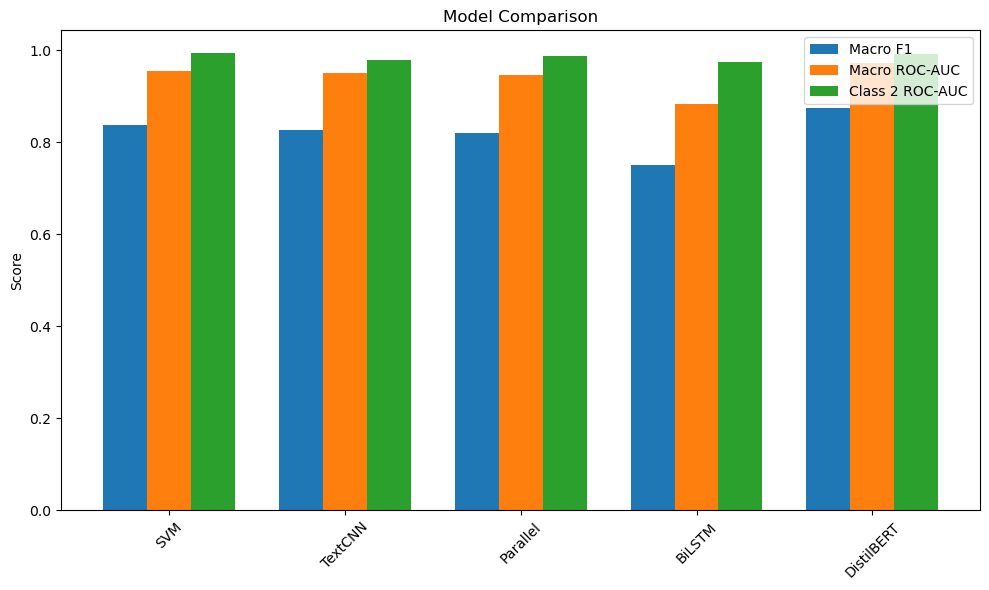

In [26]:
models = ['SVM', 'TextCNN', 'Parallel', 'BiLSTM', 'DistilBERT']
macro_f1 = [report_svm['macro avg']['f1-score'],
            report_cnn['macro avg']['f1-score'],
            report_par['macro avg']['f1-score'],
            report_bilstm['macro avg']['f1-score'],
            report_bert['macro avg']['f1-score']]
macro_auc = [roc_auc_svm, roc_auc_cnn, roc_auc_par, roc_auc_bilstm, roc_auc_bert]
c2_auc = [svm_auc_c2, cnn_auc_c2, par_auc_c2, bilstm_auc_c2, bert_auc_c2]

comp_df = pd.DataFrame({
    'Model': models,
    'Macro F1': macro_f1,
    'Macro ROC-AUC': macro_auc,
    'Class 2 ROC-AUC': c2_auc
})
print("\n=== FINAL COMPARISON TABLE ===")
print(comp_df)
comp_df.to_csv('results/model_comparison.csv', index=False)

# Plot
plt.figure(figsize=(10,6))
x = np.arange(len(models))
width = 0.25
plt.bar(x - width, macro_f1, width, label='Macro F1')
plt.bar(x, macro_auc, width, label='Macro ROC-AUC')
plt.bar(x + width, c2_auc, width, label='Class 2 ROC-AUC')
plt.xticks(x, models, rotation=45)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('figures/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

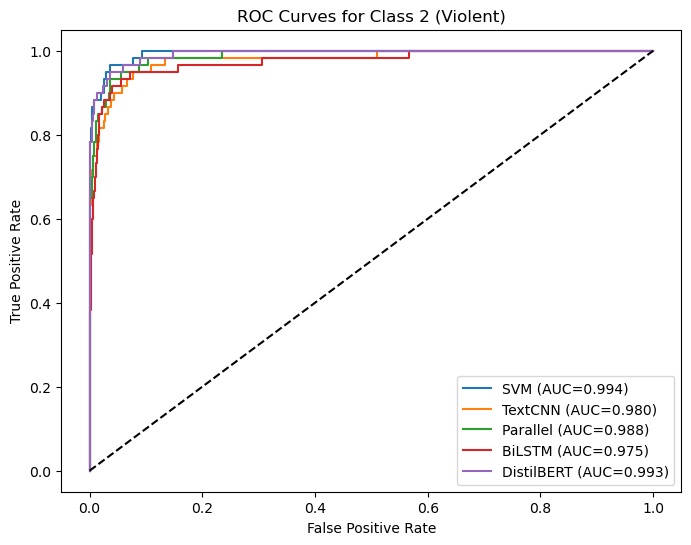


All results saved in 'results/' and 'figures/' folders.


In [34]:
# ====================================================
# ROC CURVES FOR CLASS 2 (VIOLENT) – ALL 5 MODELS
# ====================================================

# Ensure y_test is defined and is a numpy array
y_test_bin_class2 = (y_test == 2).astype(int)

# Collect scores (probabilities or decision function for class 2)
scores = []
model_names = []

# 1. SVM (decision function for class 2)
if 'svm' in globals():
    scores.append(svm.decision_function(X_test_tfidf)[:, 2])
    model_names.append('SVM')

# 2. TextCNN
if 'y_pred_cnn' in globals():
    scores.append(y_pred_cnn[:, 2])
    model_names.append('TextCNN')

# 3. Parallel CNN-BiGRU+Attention
if 'y_pred_par' in globals():
    scores.append(y_pred_par[:, 2])
    model_names.append('Parallel')

# 4. BiLSTM
if 'y_pred_bilstm' in globals():
    scores.append(y_pred_bilstm[:, 2])
    model_names.append('BiLSTM')

# 5. DistilBERT (probabilities)
if 'y_pred_bert_probs' in globals():
    scores.append(y_pred_bert_probs[:, 2])
    model_names.append('DistilBERT')
elif 'y_pred_bert_class' in globals():
    # fallback: if only class predictions exist, we cannot draw ROC; warn
    print("Warning: DistilBERT probabilities not found. ROC curve will be omitted.")
else:
    print("No DistilBERT predictions found.")

if len(scores) == 0:
    raise ValueError("No valid score arrays found. Make sure models have been run.")

# Plot ROC curves
plt.figure(figsize=(8,6))
for name, sc in zip(model_names, scores):
    fpr, tpr, _ = roc_curve(y_test_bin_class2, sc)
    auc_val = roc_auc_score(y_test_bin_class2, sc)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Class 2 (Violent)')
plt.legend()
plt.savefig('figures/roc_class2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll results saved in 'results/' and 'figures/' folders.")

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_bert_class)
print(cm)